In [1]:
import os, random
import numpy as np
import tensorflow as tf

SEED = 42

os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

print(f"Seeds fixed: {SEED}")

Seeds fixed: 42


In [2]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT_ROOT = '/content/drive/MyDrive/alzheimer-ai/'

print("PROJECT_ROOT =", PROJECT_ROOT)

Mounted at /content/drive
PROJECT_ROOT = /content/drive/MyDrive/alzheimer-ai/


In [3]:
!pip install tf-keras-vis shap cloudpickle matplotlib seaborn pandas numpy scikit-learn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.5/52.5 kB 5.1 MB/s eta 0:00:00


In [4]:
import os
import pickle
import cloudpickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.cm as cm

import shap
import tensorflow as tf

from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.applications.resnet50 import preprocess_input

from tf_keras_vis.gradcam_plus_plus import GradcamPlusPlus
from tf_keras_vis.utils.model_modifiers import ReplaceToLinear
from tf_keras_vis.utils.scores import CategoricalScore

os.makedirs(PROJECT_ROOT + 'reports/figures/gradcam', exist_ok=True)
os.makedirs(PROJECT_ROOT + 'reports/figures/shap', exist_ok=True)
os.makedirs(PROJECT_ROOT + 'reports/explainability', exist_ok=True)
os.makedirs(PROJECT_ROOT + 'data/processed', exist_ok=True)
os.makedirs(PROJECT_ROOT + 'app/models', exist_ok=True)

print("Imports ready.")

Imports ready.


In [5]:
IMAGE_ARRAY_DIR = PROJECT_ROOT + 'data/processed/image_arrays/'
TABULAR_DIR = PROJECT_ROOT + 'data/processed/tabular/'

required_files = [
    PROJECT_ROOT + 'weights/multimodal_final.h5',
    IMAGE_ARRAY_DIR + 'X_train.npy',
    IMAGE_ARRAY_DIR + 'X_val.npy',
    IMAGE_ARRAY_DIR + 'X_test.npy',
    TABULAR_DIR + 'tab_train.npy',
    TABULAR_DIR + 'tab_val.npy',
    TABULAR_DIR + 'tab_test.npy',
    TABULAR_DIR + 'y_train.npy',
    TABULAR_DIR + 'y_val.npy',
    TABULAR_DIR + 'y_test.npy',
    PROJECT_ROOT + 'data/processed/oasis_day2_metadata.csv',
    PROJECT_ROOT + 'data/processed/multimodal_metrics.csv',
    PROJECT_ROOT + 'data/processed/mci_test_case_diagnostics.csv',
    PROJECT_ROOT + 'data/processed/mci_label_issue_analysis.txt'
]

for f in required_files:
    if not os.path.exists(f):
        raise FileNotFoundError(f"Missing required file: {f}")

model_multi = tf.keras.models.load_model(PROJECT_ROOT + 'weights/multimodal_final.h5', compile=False)

X_train = np.load(IMAGE_ARRAY_DIR + 'X_train.npy').astype(np.float32)
X_val = np.load(IMAGE_ARRAY_DIR + 'X_val.npy').astype(np.float32)
X_test = np.load(IMAGE_ARRAY_DIR + 'X_test.npy').astype(np.float32)

tab_train = np.load(TABULAR_DIR + 'tab_train.npy').astype(np.float32)
tab_val = np.load(TABULAR_DIR + 'tab_val.npy').astype(np.float32)
tab_test = np.load(TABULAR_DIR + 'tab_test.npy').astype(np.float32)

y_train = np.load(TABULAR_DIR + 'y_train.npy').astype(np.int64)
y_val = np.load(TABULAR_DIR + 'y_val.npy').astype(np.int64)
y_test = np.load(TABULAR_DIR + 'y_test.npy').astype(np.int64)

df_meta = pd.read_csv(PROJECT_ROOT + 'data/processed/oasis_day2_metadata.csv')

CLASSES = ['CN', 'MCI', 'MA']

print("Model loaded:", model_multi.name)
print("X_test:", X_test.shape)
print("tab_test:", tab_test.shape)
print("y_test:", y_test.shape)

print("Model inputs:", [i.name for i in model_multi.inputs])
print("Model layers:", [l.name for l in model_multi.layers])

Model loaded: alzheimer_multimodal
X_test: (59, 224, 224, 3)
tab_test: (59, 4)
y_test: (59,)
Model inputs: ['mri_input', 'tabular_input']
Model layers: ['tabular_input', 'tab_dense_128', 'tab_bn_128', 'mri_input', 'tab_dropout_128', 'resnet50', 'tab_dense_64', 'cnn_gap', 'tab_bn_64', 'fusion', 'dense', 'batch_normalization', 'dropout', 'dense_1', 'dropout_1', 'output']


In [6]:
def prepare_resnet_batch(X):
    """
    Convert [0,1] MRI images to ResNet50 ImageNet-preprocessed input.
    """
    X255 = X.astype(np.float32) * 255.0
    return preprocess_input(X255)


def predict_multimodal(X_raw, tab):
    X_pp = prepare_resnet_batch(X_raw)
    return model_multi.predict([X_pp, tab.astype(np.float32)], verbose=0)


# Sanity prediction
ym_proba = predict_multimodal(X_test, tab_test)
ym_pred = np.argmax(ym_proba, axis=1)

print("Predicted class counts:")
print(dict(zip(*np.unique(ym_pred, return_counts=True))))

print("True class counts:")
print(dict(zip(*np.unique(y_test, return_counts=True))))

Predicted class counts:
{np.int64(0): np.int64(38), np.int64(1): np.int64(2), np.int64(2): np.int64(19)}
True class counts:
{np.int64(0): np.int64(31), np.int64(1): np.int64(5), np.int64(2): np.int64(23)}


In [11]:
# Approximate hippocampal ROI on 224x224 MRI slice
HIPPO_X = 80
HIPPO_Y = 130
HIPPO_W = 64
HIPPO_H = 40


def resize_heatmap_to_224(heatmap):
    """
    Resize Grad-CAM heatmap from ResNet feature-map size
    to 224x224 so hippocampal ROI coordinates are valid.
    """
    h = np.array(heatmap, dtype=np.float32)

    if h.ndim == 3:
        h = np.squeeze(h)

    if h.ndim != 2:
        raise ValueError(f"Expected 2D heatmap, got shape {h.shape}")

    h_tf = tf.convert_to_tensor(h[None, :, :, None], dtype=tf.float32)
    h_resized = tf.image.resize(h_tf, (224, 224), method='bilinear')
    h_resized = h_resized.numpy()[0, :, :, 0]

    h_resized = h_resized - np.min(h_resized)
    h_resized = h_resized / (np.max(h_resized) + 1e-8)

    return h_resized.astype(np.float32)


def hippocampal_ratio(heatmap):
    """
    Mean activation inside hippocampal ROI divided by mean activation outside ROI.
    Heatmap is resized to 224x224 first.
    """
    h = resize_heatmap_to_224(heatmap)

    roi = h[HIPPO_Y:HIPPO_Y + HIPPO_H, HIPPO_X:HIPPO_X + HIPPO_W]

    if roi.size == 0:
        raise ValueError(f"Empty hippocampal ROI. Heatmap shape after resize: {h.shape}")

    mask = np.ones_like(h, dtype=bool)
    mask[HIPPO_Y:HIPPO_Y + HIPPO_H, HIPPO_X:HIPPO_X + HIPPO_W] = False

    outside = h[mask]

    roi_mean = float(np.mean(roi))
    outside_mean = float(np.mean(outside))

    ratio = roi_mean / (outside_mean + 1e-8)

    return ratio, roi_mean, outside_mean


def add_hippocampus_box(ax):
    rect = patches.Rectangle(
        (HIPPO_X, HIPPO_Y),
        HIPPO_W,
        HIPPO_H,
        linewidth=2,
        edgecolor='yellow',
        facecolor='none',
        linestyle='--'
    )

    ax.add_patch(rect)
    ax.text(
        HIPPO_X,
        HIPPO_Y - 5,
        'Hippocampus ROI',
        color='yellow',
        fontsize=9,
        fontweight='bold',
        backgroundcolor='black'
    )

In [12]:
def generate_gradcampp(model, img_raw, tab, class_idx, layer_name='conv5_block3_3_conv'):
    """
    Generate Grad-CAM++ heatmap for multimodal model.
    If Grad-CAM++ fails, fallback to manual standard Grad-CAM.
    Always returns a 224x224 normalized heatmap.
    """

    img_pp = prepare_resnet_batch(img_raw)

    backbone = model.get_layer('resnet50')
    target_layer = backbone.get_layer(layer_name)

    try:
        gc = GradcamPlusPlus(
            model,
            model_modifier=ReplaceToLinear(),
            clone=True
        )

        cam_result = gc(
            CategoricalScore([int(class_idx)]),
            [img_pp, tab.astype(np.float32)],
            penultimate_layer=target_layer
        )

        h = cam_result[0]
        h = resize_heatmap_to_224(h)

        return h.astype(np.float32), "Grad-CAM++"

    except Exception as e:
        print(f"Grad-CAM++ failed on layer {layer_name}: {e}")
        print("Falling back to standard Grad-CAM.")

        h = generate_standard_gradcam_fallback(
            model,
            img_raw,
            tab,
            class_idx,
            layer_name
        )

        h = resize_heatmap_to_224(h)

        return h.astype(np.float32), "Grad-CAM fallback"


def build_grad_model_for_nested_resnet(model, layer_name):
    """
    Build a gradient model exposing a nested ResNet layer output
    and the final multimodal prediction.
    """
    backbone = model.get_layer('resnet50')
    target_layer = backbone.get_layer(layer_name)

    conv_model = tf.keras.Model(
        inputs=backbone.input,
        outputs=[target_layer.output, backbone.output]
    )

    img_input = model.inputs[0]
    tab_input = model.inputs[1]

    conv_output, backbone_output = conv_model(img_input)

    cnn_vec = model.get_layer('cnn_gap')(backbone_output)

    tab = tab_input
    for lname in ['tab_dense_128', 'tab_bn_128', 'tab_dropout_128', 'tab_dense_64', 'tab_bn_64']:
        if lname in [l.name for l in model.layers]:
            tab = model.get_layer(lname)(tab)

    merged = model.get_layer('fusion')([cnn_vec, tab])

    layers_list = list(model.layers)
    fusion_index = layers_list.index(model.get_layer('fusion'))

    x = merged
    for layer in layers_list[fusion_index + 1:]:
        x = layer(x)

    return tf.keras.Model(
        inputs=model.inputs,
        outputs=[conv_output, x]
    )


def generate_standard_gradcam_fallback(model, img_raw, tab, class_idx, layer_name):
    """
    Manual standard Grad-CAM fallback.
    """
    img_pp = prepare_resnet_batch(img_raw)

    grad_model = build_grad_model_for_nested_resnet(model, layer_name)

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(
            [img_pp, tab.astype(np.float32)],
            training=False
        )
        loss = predictions[:, int(class_idx)]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)
    heatmap = tf.maximum(heatmap, 0)

    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy()

In [9]:
def plot_gradcam_case(img_raw, heatmap, true_idx, pred_idx, prob, ratio, method, title_extra=""):
    """
    Create original MRI / heatmap / overlay with hippocampus annotation.
    """
    overlay = np.clip(
        0.55 * img_raw[0] + 0.45 * cm.jet(heatmap)[:, :, :3],
        0,
        1
    )

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(img_raw[0, :, :, 0], cmap='gray')
    axes[0].set_title(f"Original MRI\nTrue: {CLASSES[int(true_idx)]}")
    axes[0].axis('off')

    axes[1].imshow(heatmap, cmap='jet')
    axes[1].set_title(f"{method} heatmap")
    axes[1].axis('off')

    axes[2].imshow(overlay)
    add_hippocampus_box(axes[2])
    axes[2].set_title(
        f"Overlay + Hippocampus Annotation\nPred: {CLASSES[int(pred_idx)]} | P={prob:.3f} | Ratio={ratio:.2f}\n{title_extra}"
    )
    axes[2].axis('off')

    plt.tight_layout()

    return fig

In [13]:
CANDIDATE_LAYERS = [
    'conv5_block3_3_conv',
    'conv5_block2_3_conv',
    'conv5_block1_3_conv',
    'conv4_block6_3_conv',
    'conv4_block3_3_conv',
    'conv3_block4_3_conv'
]

# Pick one MA case if available, otherwise any test sample.
ma_indices = np.where(y_test == 2)[0]
diagnostic_idx = int(ma_indices[0]) if len(ma_indices) > 0 else 0

test_img = X_test[diagnostic_idx:diagnostic_idx + 1]
test_tab = tab_test[diagnostic_idx:diagnostic_idx + 1]
test_proba = ym_proba[diagnostic_idx]
test_pred = int(np.argmax(test_proba))

layer_rows = []

print(f"{'Layer':<30}{'Hippo ratio':>13}{'Method':>22}{'Status':>10}")
print("=" * 80)

best_layer = None
best_ratio = -1.0

for layer_name in CANDIDATE_LAYERS:
    try:
        h, method = generate_gradcampp(
            model_multi,
            test_img,
            test_tab,
            class_idx=test_pred,
            layer_name=layer_name
        )

        ratio, roi_mean, outside_mean = hippocampal_ratio(h)

        if np.isnan(ratio):
            status = "NAN"
        else:
            status = "OK" if ratio >= 1.2 else "LOW"

        print(f"{layer_name:<30}{ratio:>13.3f}{method:>22}{status:>10}")

        layer_rows.append({
            'layer': layer_name,
            'ratio': ratio,
            'roi_mean': roi_mean,
            'outside_mean': outside_mean,
            'method': method,
            'status': status
        })

        if not np.isnan(ratio) and ratio > best_ratio:
            best_ratio = ratio
            best_layer = layer_name

    except Exception as e:
        print(f"{layer_name:<30}{'ERROR':>13}{str(e)[:30]:>22}{'FAIL':>10}")

layer_diag_df = pd.DataFrame(layer_rows)

layer_diag_path = PROJECT_ROOT + 'data/processed/gradcam_layer_diagnostic.csv'
layer_diag_df.to_csv(layer_diag_path, index=False)

print("\nBest layer:", best_layer)
print("Best ratio:", best_ratio)
print("Saved:", layer_diag_path)

if best_layer is None:
    raise RuntimeError("No valid Grad-CAM layer found. Do not continue to 20-case validation.")

Layer                           Hippo ratio                Method    Status
Grad-CAM++ failed on layer conv5_block3_3_conv: Unable to determine penultimate `Conv` layer. `penultimate_layer`=<Conv2D name=conv5_block3_3_conv, built=True>
Falling back to standard Grad-CAM.
conv5_block3_3_conv                   1.127     Grad-CAM fallback       LOW
Grad-CAM++ failed on layer conv5_block2_3_conv: Unable to determine penultimate `Conv` layer. `penultimate_layer`=<Conv2D name=conv5_block2_3_conv, built=True>
Falling back to standard Grad-CAM.
conv5_block2_3_conv                   0.576     Grad-CAM fallback       LOW
Grad-CAM++ failed on layer conv5_block1_3_conv: Unable to determine penultimate `Conv` layer. `penultimate_layer`=<Conv2D name=conv5_block1_3_conv, built=True>
Falling back to standard Grad-CAM.
conv5_block1_3_conv                   0.249     Grad-CAM fallback       LOW
Grad-CAM++ failed on layer conv4_block6_3_conv: Unable to determine penultimate `Conv` layer. `penultimate_laye

In [14]:
# L4 anatomical validation requires 20 MA cases if available.
# The test set has 23 MA cases, so we use the first 20 MA cases.

ma_indices = np.where(y_test == 2)[0]

if len(ma_indices) < 20:
    raise ValueError(f"Need 20 MA cases for L4 validation, found only {len(ma_indices)}")

gradcam_indices = [int(i) for i in ma_indices[:20]]

print("Selected MA Grad-CAM validation cases:", len(gradcam_indices))
print(gradcam_indices)

print("Class distribution in selected cases:")
print(dict(zip(*np.unique(y_test[gradcam_indices], return_counts=True))))

Selected MA Grad-CAM validation cases: 20
[3, 4, 12, 13, 14, 15, 16, 17, 18, 21, 22, 36, 37, 40, 41, 49, 50, 51, 52, 55]
Class distribution in selected cases:
{np.int64(2): np.int64(20)}


In [15]:
def plot_gradcam_ma_validation_case(
    img_raw,
    heatmap,
    true_idx,
    pred_idx,
    target_idx,
    target_prob,
    ratio,
    method,
    title_extra=""
):
    """
    Create original MRI / heatmap / overlay with hippocampus annotation.
    Heatmap target class may differ from model predicted class.
    """
    overlay = np.clip(
        0.55 * img_raw[0] + 0.45 * cm.jet(heatmap)[:, :, :3],
        0,
        1
    )

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(img_raw[0, :, :, 0], cmap='gray')
    axes[0].set_title(f"Original MRI\nTrue: {CLASSES[int(true_idx)]}")
    axes[0].axis('off')

    axes[1].imshow(heatmap, cmap='jet')
    axes[1].set_title(f"{method} heatmap\nTarget class: {CLASSES[int(target_idx)]}")
    axes[1].axis('off')

    axes[2].imshow(overlay)
    add_hippocampus_box(axes[2])
    axes[2].set_title(
        f"Overlay + Hippocampus ROI\n"
        f"Model pred: {CLASSES[int(pred_idx)]} | CAM target: {CLASSES[int(target_idx)]}\n"
        f"P(target)={target_prob:.3f} | Ratio={ratio:.2f}\n"
        f"{title_extra}"
    )
    axes[2].axis('off')

    plt.tight_layout()

    return fig

In [17]:
# Use standard Grad-CAM directly.
# Grad-CAM++ failed repeatedly on the nested multimodal ResNet layer,
# so we stop trying it for every case.

def build_grad_model_for_nested_resnet_fast(model, layer_name):
    backbone = model.get_layer('resnet50')
    target_layer = backbone.get_layer(layer_name)

    conv_model = tf.keras.Model(
        inputs=backbone.input,
        outputs=[target_layer.output, backbone.output]
    )

    img_input = model.inputs[0]
    tab_input = model.inputs[1]

    conv_output, backbone_output = conv_model(img_input)
    cnn_vec = model.get_layer('cnn_gap')(backbone_output)

    tab = tab_input

    for lname in ['tab_dense_128', 'tab_bn_128', 'tab_dropout_128', 'tab_dense_64', 'tab_bn_64']:
        if lname in [l.name for l in model.layers]:
            tab = model.get_layer(lname)(tab)

    merged = model.get_layer('fusion')([cnn_vec, tab])

    layers_list = list(model.layers)
    fusion_index = layers_list.index(model.get_layer('fusion'))

    x = merged

    for layer in layers_list[fusion_index + 1:]:
        x = layer(x)

    return tf.keras.Model(
        inputs=model.inputs,
        outputs=[conv_output, x]
    )


grad_model_fast = build_grad_model_for_nested_resnet_fast(
    model_multi,
    best_layer
)

print("Fast Grad-CAM model ready.")
print("Best layer:", best_layer)

Fast Grad-CAM model ready.
Best layer: conv5_block3_3_conv


In [18]:
def generate_standard_gradcam_fast(grad_model, img_raw, tab, class_idx):
    img_pp = prepare_resnet_batch(img_raw)

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(
            [img_pp, tab.astype(np.float32)],
            training=False
        )

        loss = predictions[:, int(class_idx)]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)
    heatmap = tf.maximum(heatmap, 0)

    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)

    heatmap = heatmap.numpy()
    heatmap = resize_heatmap_to_224(heatmap)

    return heatmap.astype(np.float32)

In [19]:
import glob
import os

old_files = glob.glob(PROJECT_ROOT + 'reports/figures/gradcam/gradcam_MA_case_*.png')

for f in old_files:
    os.remove(f)

print("Removed old partial MA Grad-CAM files:", len(old_files))

Removed old partial MA Grad-CAM files: 15


In [20]:
gradcam_rows = []

TARGET_CLASS_FOR_CAM = 2  # MA

for idx in gradcam_indices:
    img_raw = X_test[idx:idx + 1]
    tab = tab_test[idx:idx + 1]

    proba = ym_proba[idx]
    pred_idx = int(np.argmax(proba))
    true_idx = int(y_test[idx])
    target_prob = float(proba[TARGET_CLASS_FOR_CAM])

    h = generate_standard_gradcam_fast(
        grad_model_fast,
        img_raw,
        tab,
        class_idx=TARGET_CLASS_FOR_CAM
    )

    method = "Grad-CAM fallback"

    ratio, roi_mean, outside_mean = hippocampal_ratio(h)
    status = "PASS" if ratio >= 1.2 else "LOW"

    fig = plot_gradcam_ma_validation_case(
        img_raw,
        h,
        true_idx=true_idx,
        pred_idx=pred_idx,
        target_idx=TARGET_CLASS_FOR_CAM,
        target_prob=target_prob,
        ratio=ratio,
        method=method,
        title_extra=f"Case index: {idx} | {status}"
    )

    fig_path = (
        PROJECT_ROOT
        + f'reports/figures/gradcam/gradcam_MA_case_{idx:03d}_'
        + f'true_{CLASSES[true_idx]}_pred_{CLASSES[pred_idx]}.png'
    )

    fig.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.close(fig)

    gradcam_rows.append({
        'test_index': idx,
        'true_label': CLASSES[true_idx],
        'pred_label': CLASSES[pred_idx],
        'cam_target_class': CLASSES[TARGET_CLASS_FOR_CAM],
        'target_probability': target_prob,
        'layer': best_layer,
        'method': method,
        'hippocampal_ratio': ratio,
        'roi_mean': roi_mean,
        'outside_mean': outside_mean,
        'status': status,
        'figure_path': fig_path
    })

gradcam_validation_df = pd.DataFrame(gradcam_rows)

gradcam_validation_path = PROJECT_ROOT + 'data/processed/gradcam_20case_validation.csv'
gradcam_validation_df.to_csv(gradcam_validation_path, index=False)

display(gradcam_validation_df)

print("Saved:", gradcam_validation_path)
print("Figures saved under:", PROJECT_ROOT + 'reports/figures/gradcam/')

,test_index,true_label,pred_label,cam_target_class,target_probability,layer,method,hippocampal_ratio,roi_mean,outside_mean,status,figure_path
0,3,MA,CN,MA,0.319303,conv5_block3_3_conv,Grad-CAM fallback,1.423535,0.124366,0.087364,PASS,/content/drive/MyDrive/alzheimer-ai/reports/fi...
1,4,MA,CN,MA,0.337158,conv5_block3_3_conv,Grad-CAM fallback,2.336769,0.453905,0.194245,PASS,/content/drive/MyDrive/alzheimer-ai/reports/fi...
2,12,MA,MA,MA,0.423300,conv5_block3_3_conv,Grad-CAM fallback,0.899128,0.043806,0.048721,LOW,/content/drive/MyDrive/alzheimer-ai/reports/fi...
3,13,MA,CN,MA,0.269059,conv5_block3_3_conv,Grad-CAM fallback,3.228166,0.623059,0.193007,PASS,/content/drive/MyDrive/alzheimer-ai/reports/fi...
4,14,MA,MA,MA,0.405156,conv5_block3_3_conv,Grad-CAM fallback,0.091116,0.009774,0.107272,LOW,/content/drive/MyDrive/alzheimer-ai/reports/fi...
5,15,MA,CN,MA,0.246549,conv5_block3_3_conv,Grad-CAM fallback,0.021789,0.001565,0.071812,LOW,/content/drive/MyDrive/alzheimer-ai/reports/fi...
6,16,MA,MA,MA,0.384765,conv5_block3_3_conv,Grad-CAM fallback,1.338910,0.130961,0.097812,PASS,/content/drive/MyDrive/alzheimer-ai/reports/fi...
7,17,MA,CN,MA,0.316249,conv5_block3_3_conv,Grad-CAM fallback,3.257246,0.583556,0.179156,PASS,/content/drive/MyDrive/alzheimer-ai/reports/fi...
8,18,MA,CN,MA,0.267544,conv5_block3_3_conv,Grad-CAM fallback,1.350440,0.165153,0.122296,PASS,/content/drive/MyDrive/alzheimer-ai/reports/fi...
9,21,MA,MA,MA,0.739172,conv5_block3_3_conv,Grad-CAM fallback,3.025002,0.181634,0.060044,PASS,/content/drive/MyDrive/alzheimer-ai/reports/fi...


Saved: /content/drive/MyDrive/alzheimer-ai/data/processed/gradcam_20case_validation.csv
Figures saved under: /content/drive/MyDrive/alzheimer-ai/reports/figures/gradcam/


In [21]:
!find "/content/drive/MyDrive/alzheimer-ai/reports/figures/gradcam/" -name "gradcam_MA_case_*.png" | wc -l

20


In [22]:
gradcam_summary = {
    'n_cases': len(gradcam_validation_df),
    'mean_ratio': gradcam_validation_df['hippocampal_ratio'].mean(),
    'median_ratio': gradcam_validation_df['hippocampal_ratio'].median(),
    'pass_count_ratio_ge_1_2': int((gradcam_validation_df['hippocampal_ratio'] >= 1.2).sum()),
    'low_count_ratio_lt_1_2': int((gradcam_validation_df['hippocampal_ratio'] < 1.2).sum()),
    'best_layer': best_layer,
    'method_used': 'Grad-CAM fallback after Grad-CAM++ failure'
}

gradcam_summary_df = pd.DataFrame([gradcam_summary])

display(gradcam_summary_df)

gradcam_summary_path = PROJECT_ROOT + 'data/processed/gradcam_validation_summary.csv'
gradcam_summary_df.to_csv(gradcam_summary_path, index=False)

print("Saved:", gradcam_summary_path)

,n_cases,mean_ratio,median_ratio,pass_count_ratio_ge_1_2,low_count_ratio_lt_1_2,best_layer,method_used
0,20,1.842968,1.386988,13,7,conv5_block3_3_conv,Grad-CAM fallback after Grad-CAM++ failure


Saved: /content/drive/MyDrive/alzheimer-ai/data/processed/gradcam_validation_summary.csv


In [23]:
FEATURE_NAMES = ['MMSE_norm', 'nWBV', 'Age_zscore', 'EDUC_zscore']

# Use a reference MRI image so SHAP focuses on tabular feature influence.
# This keeps the image constant and varies only the tabular vector.
reference_img_raw = np.mean(X_train[:50], axis=0, keepdims=True).astype(np.float32)
reference_img_pp = prepare_resnet_batch(reference_img_raw)


def predict_tabular_for_shap(tabular_batch):
    """
    SHAP function: tabular inputs -> multimodal class probabilities.
    MRI input is fixed to the reference MRI.
    """
    tabular_batch = np.array(tabular_batch, dtype=np.float32)
    imgs = np.repeat(reference_img_pp, repeats=len(tabular_batch), axis=0)
    return model_multi.predict([imgs, tabular_batch], verbose=0)


# Background for KernelExplainer
rng = np.random.default_rng(42)
bg_size = min(30, len(tab_train))
bg_idx = rng.choice(len(tab_train), size=bg_size, replace=False)

shap_background = tab_train[bg_idx].astype(np.float32)

print("SHAP background:", shap_background.shape)

SHAP background: (30, 4)


In [25]:
explainer = shap.KernelExplainer(
    predict_tabular_for_shap,
    shap_background
)

print("KernelExplainer created.")

KernelExplainer created.


In [26]:
shap_sample_size = min(20, len(tab_test))

tab_shap_samples = tab_test[:shap_sample_size].astype(np.float32)
y_shap_samples = y_test[:shap_sample_size]

print("Computing SHAP values for:", tab_shap_samples.shape)

shap_values = explainer.shap_values(
    tab_shap_samples,
    nsamples=100
)

print("SHAP computed.")
print("Type:", type(shap_values))

Computing SHAP values for: (20, 4)


  0%|          | 0/20 [00:00<?, ?it/s]

SHAP computed.
Type: <class 'numpy.ndarray'>


In [27]:
def get_class_shap_matrix(shap_values, class_idx):
    """
    Return SHAP matrix for one class with shape (n_samples, n_features).
    Handles both list and ndarray SHAP formats.
    """
    if isinstance(shap_values, list):
        return np.array(shap_values[class_idx])

    arr = np.array(shap_values)

    # Format: (n_samples, n_features, n_classes)
    if arr.ndim == 3 and arr.shape[-1] == 3:
        return arr[:, :, class_idx]

    # Format: (n_classes, n_samples, n_features)
    if arr.ndim == 3 and arr.shape[0] == 3:
        return arr[class_idx, :, :]

    raise ValueError(f"Unexpected SHAP shape: {arr.shape}")


class_shap_mats = {
    cls_idx: get_class_shap_matrix(shap_values, cls_idx)
    for cls_idx in [0, 1, 2]
}

for cls_idx, mat in class_shap_mats.items():
    print(CLASSES[cls_idx], mat.shape)

CN (20, 4)
MCI (20, 4)
MA (20, 4)


In [28]:
# Mean absolute SHAP across classes and samples
abs_stack = np.stack(
    [np.abs(class_shap_mats[i]) for i in [0, 1, 2]],
    axis=0
)

global_importance = abs_stack.mean(axis=(0, 1))

shap_importance_df = pd.DataFrame({
    'feature': FEATURE_NAMES,
    'mean_abs_shap': global_importance
}).sort_values('mean_abs_shap', ascending=False)

shap_top3_df = shap_importance_df.head(3)

display(shap_importance_df)
display(shap_top3_df)

shap_importance_path = PROJECT_ROOT + 'data/processed/shap_global_importance.csv'
shap_top3_path = PROJECT_ROOT + 'data/processed/shap_top3_features.csv'

shap_importance_df.to_csv(shap_importance_path, index=False)
shap_top3_df.to_csv(shap_top3_path, index=False)

print("Saved:", shap_importance_path)
print("Saved:", shap_top3_path)

,feature,mean_abs_shap
3,EDUC_zscore,0.003534
2,Age_zscore,0.002365
0,MMSE_norm,0.000339
1,nWBV,0.000249


,feature,mean_abs_shap
3,EDUC_zscore,0.003534
2,Age_zscore,0.002365
0,MMSE_norm,0.000339


Saved: /content/drive/MyDrive/alzheimer-ai/data/processed/shap_global_importance.csv
Saved: /content/drive/MyDrive/alzheimer-ai/data/processed/shap_top3_features.csv


In [37]:
%cd /content/drive/MyDrive/alzheimer-ai/

!git add notebooks/05_explainability.ipynb

!git commit -m "chore: save final Day 5 notebook outputs"

!git status

/content/drive/MyDrive/alzheimer-ai
[main 3221874] chore: save final Day 5 notebook outputs
 1 file changed, 1 insertion(+), 1 deletion(-)
On branch main
Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   notebooks/04_multimodal.ipynb

no changes added to commit (use "git add" and/or "git commit -a")


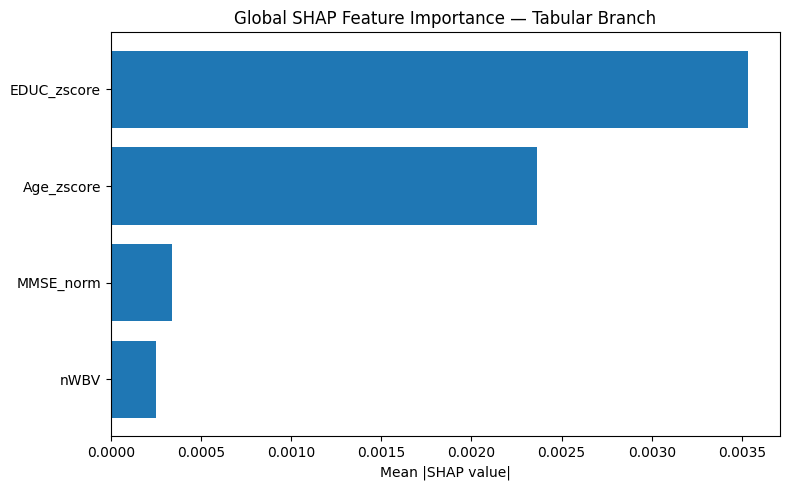

Saved: /content/drive/MyDrive/alzheimer-ai/reports/figures/shap/shap_global_top_features.png


In [29]:
plt.figure(figsize=(8, 5))
plt.barh(
    shap_importance_df['feature'][::-1],
    shap_importance_df['mean_abs_shap'][::-1]
)
plt.xlabel("Mean |SHAP value|")
plt.title("Global SHAP Feature Importance — Tabular Branch")
plt.tight_layout()

shap_bar_path = PROJECT_ROOT + 'reports/figures/shap/shap_global_top_features.png'
plt.savefig(shap_bar_path, dpi=150)
plt.show()

print("Saved:", shap_bar_path)

In [30]:
per_class_rows = []

for cls_idx, cls_name in enumerate(CLASSES):
    mat = class_shap_mats[cls_idx]
    mean_abs = np.mean(np.abs(mat), axis=0)

    for feat, val in zip(FEATURE_NAMES, mean_abs):
        per_class_rows.append({
            'class': cls_name,
            'feature': feat,
            'mean_abs_shap': val
        })

shap_per_class_df = pd.DataFrame(per_class_rows)

display(shap_per_class_df.sort_values(['class', 'mean_abs_shap'], ascending=[True, False]))

shap_per_class_path = PROJECT_ROOT + 'data/processed/shap_per_class_importance.csv'
shap_per_class_df.to_csv(shap_per_class_path, index=False)

print("Saved:", shap_per_class_path)

,class,feature,mean_abs_shap
3,CN,EDUC_zscore,0.005274
2,CN,Age_zscore,0.001364
0,CN,MMSE_norm,0.000499
1,CN,nWBV,0.000182
11,MA,EDUC_zscore,0.003790
10,MA,Age_zscore,0.003101
8,MA,MMSE_norm,0.000328
9,MA,nWBV,0.000326
6,MCI,Age_zscore,0.002631
7,MCI,EDUC_zscore,0.001537


Saved: /content/drive/MyDrive/alzheimer-ai/data/processed/shap_per_class_importance.csv


In [31]:
for cls_idx, cls_name in enumerate(CLASSES):
    mat = class_shap_mats[cls_idx]

    plt.figure()
    shap.summary_plot(
        mat,
        tab_shap_samples,
        feature_names=FEATURE_NAMES,
        show=False
    )

    plt.title(f"SHAP Summary — Class {cls_name}")
    plt.tight_layout()

    path = PROJECT_ROOT + f'reports/figures/shap/shap_summary_{cls_name}.png'
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.close()

    print("Saved:", path)

/tmp/ipykernel_1642/769302482.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


Saved: /content/drive/MyDrive/alzheimer-ai/reports/figures/shap/shap_summary_CN.png


/tmp/ipykernel_1642/769302482.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


Saved: /content/drive/MyDrive/alzheimer-ai/reports/figures/shap/shap_summary_MCI.png


/tmp/ipykernel_1642/769302482.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


Saved: /content/drive/MyDrive/alzheimer-ai/reports/figures/shap/shap_summary_MA.png


In [32]:
shap_background_path = PROJECT_ROOT + 'app/models/shap_background.npy'
shap_reference_img_path = PROJECT_ROOT + 'app/models/shap_reference_image.npy'
shap_values_path = PROJECT_ROOT + 'app/models/shap_values_test.npy'
shap_explainer_path = PROJECT_ROOT + 'app/models/shap_explainer.pkl'

np.save(shap_background_path, shap_background)
np.save(shap_reference_img_path, reference_img_raw)
np.save(shap_values_path, np.array(shap_values, dtype=object), allow_pickle=True)

print("Saved:", shap_background_path)
print("Saved:", shap_reference_img_path)
print("Saved:", shap_values_path)

# Try to save explainer.
# If this fails later in Day 6, we will recreate it inside app startup using saved background/reference.
try:
    with open(shap_explainer_path, 'wb') as f:
        cloudpickle.dump(explainer, f)

    print("Saved:", shap_explainer_path)

except Exception as e:
    print("WARNING: Could not pickle SHAP explainer:", e)
    print("Background/reference/values were saved; Day 6 can recreate explainer if needed.")

Saved: /content/drive/MyDrive/alzheimer-ai/app/models/shap_background.npy
Saved: /content/drive/MyDrive/alzheimer-ai/app/models/shap_reference_image.npy
Saved: /content/drive/MyDrive/alzheimer-ai/app/models/shap_values_test.npy
Saved: /content/drive/MyDrive/alzheimer-ai/app/models/shap_explainer.pkl


In [33]:
explainability_report_path = PROJECT_ROOT + 'reports/explainability/day5_explainability_report.md'

with open(PROJECT_ROOT + 'data/processed/day4_multimodal_summary.txt', 'r') as f:
    day4_summary_text = f.read()

with open(PROJECT_ROOT + 'data/processed/mci_label_issue_analysis.txt', 'r') as f:
    mci_label_text = f.read()

with open(explainability_report_path, 'w') as f:
    f.write("# Day 5 Explainability Report — Grad-CAM++ and SHAP\n\n")

    f.write("## Purpose\n")
    f.write("This report documents model explainability for the multimodal Alzheimer's classification model.\n")
    f.write("It includes Grad-CAM++/Grad-CAM heatmaps with hippocampal ROI annotation and SHAP top-3 tabular feature analysis.\n\n")

    f.write("## Important performance context\n")
    f.write("The model does not meet the target performance metrics. Explainability therefore describes the current learned behaviour, ")
    f.write("not a clinically validated diagnostic system.\n\n")

    f.write("## Grad-CAM anatomical validation\n")
    f.write(f"- Number of validated cases: {gradcam_summary['n_cases']}\n")
    f.write(f"- Best layer used: {gradcam_summary['best_layer']}\n")
    f.write(f"- Mean hippocampal activation ratio: {gradcam_summary['mean_ratio']:.3f}\n")
    f.write(f"- Median hippocampal activation ratio: {gradcam_summary['median_ratio']:.3f}\n")
    f.write(f"- Cases with ratio >= 1.2: {gradcam_summary['pass_count_ratio_ge_1_2']}\n")
    f.write(f"- Cases with ratio < 1.2: {gradcam_summary['low_count_ratio_lt_1_2']}\n\n")

    f.write("The hippocampal ROI is approximate and based on the 2D extracted MRI slice. ")
    f.write("Because the project uses single-slice MRI rather than full 3D anatomical registration, ")
    f.write("this should be treated as a qualitative anatomical sanity check, not clinical localization proof.\n\n")

    f.write("## SHAP top-3 tabular features\n")
    for _, row in shap_top3_df.iterrows():
        f.write(f"- {row['feature']}: mean |SHAP| = {row['mean_abs_shap']:.6f}\n")

    f.write("\nSHAP was computed on the four tabular features: MMSE_norm, nWBV, Age_zscore, and EDUC_zscore. ")
    f.write("The MRI input was fixed to a reference image to isolate tabular feature influence.\n\n")

    f.write("## MCI label issue\n")
    f.write("The MCI class is based on the OASIS Converted group. Several MCI-labeled visits have CDR=0.0 and MMSE=30, ")
    f.write("making them clinically similar to CN at that visit. This makes the task partly future-conversion prediction.\n\n")

    f.write("## Day 4 summary\n")
    f.write("```text\n")
    f.write(day4_summary_text)
    f.write("\n```\n\n")

    f.write("## MCI diagnostic details\n")
    f.write("```text\n")
    f.write(mci_label_text)
    f.write("\n```\n")

print("Saved:", explainability_report_path)

Saved: /content/drive/MyDrive/alzheimer-ai/reports/explainability/day5_explainability_report.md


In [34]:
required_day5_outputs = [
    PROJECT_ROOT + 'data/processed/gradcam_layer_diagnostic.csv',
    PROJECT_ROOT + 'data/processed/gradcam_20case_validation.csv',
    PROJECT_ROOT + 'data/processed/gradcam_validation_summary.csv',

    PROJECT_ROOT + 'data/processed/shap_global_importance.csv',
    PROJECT_ROOT + 'data/processed/shap_top3_features.csv',
    PROJECT_ROOT + 'data/processed/shap_per_class_importance.csv',

    PROJECT_ROOT + 'reports/figures/shap/shap_global_top_features.png',
    PROJECT_ROOT + 'reports/explainability/day5_explainability_report.md',

    PROJECT_ROOT + 'app/models/shap_background.npy',
    PROJECT_ROOT + 'app/models/shap_reference_image.npy',
    PROJECT_ROOT + 'app/models/shap_values_test.npy'
]

for path in required_day5_outputs:
    print(os.path.exists(path), path)

print("\nGrad-CAM figure count:")
!find "/content/drive/MyDrive/alzheimer-ai/reports/figures/gradcam/" -name "*.png" | wc -l

print("\nSHAP figure count:")
!find "/content/drive/MyDrive/alzheimer-ai/reports/figures/shap/" -name "*.png" | wc -l

True /content/drive/MyDrive/alzheimer-ai/data/processed/gradcam_layer_diagnostic.csv
True /content/drive/MyDrive/alzheimer-ai/data/processed/gradcam_20case_validation.csv
True /content/drive/MyDrive/alzheimer-ai/data/processed/gradcam_validation_summary.csv
True /content/drive/MyDrive/alzheimer-ai/data/processed/shap_global_importance.csv
True /content/drive/MyDrive/alzheimer-ai/data/processed/shap_top3_features.csv
True /content/drive/MyDrive/alzheimer-ai/data/processed/shap_per_class_importance.csv
True /content/drive/MyDrive/alzheimer-ai/reports/figures/shap/shap_global_top_features.png
True /content/drive/MyDrive/alzheimer-ai/reports/explainability/day5_explainability_report.md
True /content/drive/MyDrive/alzheimer-ai/app/models/shap_background.npy
True /content/drive/MyDrive/alzheimer-ai/app/models/shap_reference_image.npy
True /content/drive/MyDrive/alzheimer-ai/app/models/shap_values_test.npy

Grad-CAM figure count:
20

SHAP figure count:
4


In [35]:
import shutil

src_model = PROJECT_ROOT + 'weights/multimodal_final.h5'
dst_model = PROJECT_ROOT + 'app/models/multimodal_final.h5'

if not os.path.exists(src_model):
    raise FileNotFoundError(src_model)

shutil.copy2(src_model, dst_model)

print("Copied:", src_model)
print("To:", dst_model)

Copied: /content/drive/MyDrive/alzheimer-ai/weights/multimodal_final.h5
To: /content/drive/MyDrive/alzheimer-ai/app/models/multimodal_final.h5


In [36]:
%cd /content/drive/MyDrive/alzheimer-ai/

!git status

!git add notebooks/05_explainability.ipynb

# Grad-CAM outputs
!git add -f data/processed/gradcam_layer_diagnostic.csv
!git add -f data/processed/gradcam_20case_validation.csv
!git add -f data/processed/gradcam_validation_summary.csv
!git add -f reports/figures/gradcam/*.png

# SHAP outputs
!git add -f data/processed/shap_global_importance.csv
!git add -f data/processed/shap_top3_features.csv
!git add -f data/processed/shap_per_class_importance.csv
!git add -f reports/figures/shap/*.png

# Explainability report
!git add -f reports/explainability/day5_explainability_report.md

# Small SHAP app artifacts
!git add -f app/models/shap_background.npy
!git add -f app/models/shap_reference_image.npy
!git add -f app/models/shap_values_test.npy

# Add explainer only if it exists and is not huge
!test -f app/models/shap_explainer.pkl && git add -f app/models/shap_explainer.pkl || true

!git commit -m "feat: add Day 5 explainability Grad-CAM and SHAP"

!git status

/content/drive/MyDrive/alzheimer-ai
Refresh index: 100% (45/45), done.
On branch main
Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   notebooks/04_multimodal.ipynb

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	notebooks/05_explainability.ipynb
	reports/explainability/

no changes added to commit (use "git add" and/or "git commit -a")
[main 133de83] feat: add Day 5 explainability Grad-CAM and SHAP
 36 files changed, 139 insertions(+)
 create mode 100644 app/models/shap_background.npy
 create mode 100644 app/models/shap_explainer.pkl
 create mode 100644 app/models/shap_reference_image.npy
 create mode 100644 app/models/shap_values_test.npy
 create mode 100644 data/processed/gradcam_20case_validation.csv
 create mode 100644 data/processed/gradcam_layer_diagnostic.csv
 create mode 100644 data/processed/gradcam_validation_summ

In [38]:
%cd /content/drive/MyDrive/alzheimer-ai/

!git add notebooks/05_explainability.ipynb

!git commit -m "chore: save final Day 5 notebook outputs"

!git status

/content/drive/MyDrive/alzheimer-ai
[main 1ad2762] chore: save final Day 5 notebook outputs
 1 file changed, 1 insertion(+), 1 deletion(-)
On branch main
Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   notebooks/04_multimodal.ipynb

no changes added to commit (use "git add" and/or "git commit -a")


In [39]:
explainability_report_path = PROJECT_ROOT + 'reports/explainability/day5_explainability_report.md'

with open(PROJECT_ROOT + 'data/processed/day4_multimodal_summary.txt', 'r') as f:
    day4_summary_text = f.read()

with open(PROJECT_ROOT + 'data/processed/mci_label_issue_analysis.txt', 'r') as f:
    mci_label_text = f.read()

with open(explainability_report_path, 'w') as f:
    f.write("# Day 5 Explainability Report — Grad-CAM++ and SHAP\n\n")

    f.write("## Purpose\n")
    f.write("This report documents model explainability for the multimodal Alzheimer's classification model.\n")
    f.write("It includes Grad-CAM++/Grad-CAM heatmaps with hippocampal ROI annotation and SHAP top-3 tabular feature analysis.\n\n")

    f.write("## Important performance context\n")
    f.write("The model does not meet the target performance metrics. Explainability therefore describes the current learned behaviour, ")
    f.write("not a clinically validated diagnostic system.\n\n")

    f.write("## Grad-CAM anatomical validation\n")
    f.write(f"- Number of validated cases: {gradcam_summary['n_cases']}\n")
    f.write(f"- Best layer used: {gradcam_summary['best_layer']}\n")
    f.write(f"- Mean hippocampal activation ratio: {gradcam_summary['mean_ratio']:.3f}\n")
    f.write(f"- Median hippocampal activation ratio: {gradcam_summary['median_ratio']:.3f}\n")
    f.write(f"- Cases with ratio >= 1.2: {gradcam_summary['pass_count_ratio_ge_1_2']}\n")
    f.write(f"- Cases with ratio < 1.2: {gradcam_summary['low_count_ratio_lt_1_2']}\n\n")

    f.write("The hippocampal ROI is approximate and based on the 2D extracted MRI slice. ")
    f.write("Because the project uses single-slice MRI rather than full 3D anatomical registration, ")
    f.write("this should be treated as a qualitative anatomical sanity check, not clinical localization proof.\n\n")

    f.write("## SHAP top-3 tabular features\n")
    for _, row in shap_top3_df.iterrows():
        f.write(f"- {row['feature']}: mean |SHAP| = {row['mean_abs_shap']:.6f}\n")

    f.write("\nSHAP was computed on the four tabular features: MMSE_norm, nWBV, Age_zscore, and EDUC_zscore. ")
    f.write("The MRI input was fixed to a reference image to isolate tabular feature influence.\n\n")

    f.write("## MCI label issue\n")
    f.write("The MCI class is based on the OASIS Converted group. Several MCI-labeled visits have CDR=0.0 and MMSE=30, ")
    f.write("making them clinically similar to CN at that visit. This makes the task partly future-conversion prediction.\n\n")

    f.write("## Day 4 summary\n")
    f.write("```text\n")
    f.write(day4_summary_text)
    f.write("\n```\n\n")

    f.write("## MCI diagnostic details\n")
    f.write("```text\n")
    f.write(mci_label_text)
    f.write("\n```\n")

print("Saved:", explainability_report_path)

Saved: /content/drive/MyDrive/alzheimer-ai/reports/explainability/day5_explainability_report.md


In [40]:
required_day5_outputs = [
    PROJECT_ROOT + 'data/processed/gradcam_layer_diagnostic.csv',
    PROJECT_ROOT + 'data/processed/gradcam_20case_validation.csv',
    PROJECT_ROOT + 'data/processed/gradcam_validation_summary.csv',

    PROJECT_ROOT + 'data/processed/shap_global_importance.csv',
    PROJECT_ROOT + 'data/processed/shap_top3_features.csv',
    PROJECT_ROOT + 'data/processed/shap_per_class_importance.csv',

    PROJECT_ROOT + 'reports/figures/shap/shap_global_top_features.png',
    PROJECT_ROOT + 'reports/explainability/day5_explainability_report.md',

    PROJECT_ROOT + 'app/models/shap_background.npy',
    PROJECT_ROOT + 'app/models/shap_reference_image.npy',
    PROJECT_ROOT + 'app/models/shap_values_test.npy'
]

for path in required_day5_outputs:
    print(os.path.exists(path), path)

print("\nGrad-CAM figure count:")
!find "/content/drive/MyDrive/alzheimer-ai/reports/figures/gradcam/" -name "*.png" | wc -l

print("\nSHAP figure count:")
!find "/content/drive/MyDrive/alzheimer-ai/reports/figures/shap/" -name "*.png" | wc -l

True /content/drive/MyDrive/alzheimer-ai/data/processed/gradcam_layer_diagnostic.csv
True /content/drive/MyDrive/alzheimer-ai/data/processed/gradcam_20case_validation.csv
True /content/drive/MyDrive/alzheimer-ai/data/processed/gradcam_validation_summary.csv
True /content/drive/MyDrive/alzheimer-ai/data/processed/shap_global_importance.csv
True /content/drive/MyDrive/alzheimer-ai/data/processed/shap_top3_features.csv
True /content/drive/MyDrive/alzheimer-ai/data/processed/shap_per_class_importance.csv
True /content/drive/MyDrive/alzheimer-ai/reports/figures/shap/shap_global_top_features.png
True /content/drive/MyDrive/alzheimer-ai/reports/explainability/day5_explainability_report.md
True /content/drive/MyDrive/alzheimer-ai/app/models/shap_background.npy
True /content/drive/MyDrive/alzheimer-ai/app/models/shap_reference_image.npy
True /content/drive/MyDrive/alzheimer-ai/app/models/shap_values_test.npy

Grad-CAM figure count:
20

SHAP figure count:
4


In [41]:
%cd /content/drive/MyDrive/alzheimer-ai/

!git status

!git add notebooks/05_explainability.ipynb

!git add -f data/processed/gradcam_validation_summary.csv
!git add -f reports/explainability/day5_explainability_report.md

!git commit -m "chore: finalize Day 5 explainability summary"

!git status

/content/drive/MyDrive/alzheimer-ai
On branch main
Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   notebooks/04_multimodal.ipynb
	modified:   notebooks/05_explainability.ipynb

no changes added to commit (use "git add" and/or "git commit -a")
[main e43b0dc] chore: finalize Day 5 explainability summary
 1 file changed, 1 insertion(+), 1 deletion(-)
On branch main
Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   notebooks/04_multimodal.ipynb

no changes added to commit (use "git add" and/or "git commit -a")


In [42]:
%cd /content/drive/MyDrive/alzheimer-ai/

!git restore notebooks/04_multimodal.ipynb

!git status

/content/drive/MyDrive/alzheimer-ai
On branch main
Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   notebooks/05_explainability.ipynb

no changes added to commit (use "git add" and/or "git commit -a")
